# 01 — Exploratory Data Analysis (EDA)

**Entrada:** `ANALYTICS.TRAIN_SET` (sample)

**Regla de oro:** Nunca cargamos más de lo necesario. Toda consulta usa `TABLESAMPLE` o `LIMIT`.  
**Objetivo:** Entender la distribución de los datos, identificar outliers y marcar columnas con Data Leakage.

## Imports y conexión

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import snowflake.connector
import warnings

warnings.filterwarnings('ignore')
load_dotenv()

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)

def get_conn():
    return snowflake.connector.connect(
        account   = os.environ['SNOWFLAKE_ACCOUNT'],
        user      = os.environ['SNOWFLAKE_USER'],
        password  = os.environ['SNOWFLAKE_PASSWORD'],
        database  = os.environ['SNOWFLAKE_DATABASE'],
        warehouse = os.environ['SNOWFLAKE_WAREHOUSE'],
        schema    = os.environ['SNOWFLAKE_SCHEMA'],
        role      = os.environ.get('SNOWFLAKE_ROLE'),
    )

def query(sql: str) -> pd.DataFrame:
    """Ejecuta SQL en Snowflake y retorna DataFrame. Siempre cierra la conexión."""
    conn = get_conn()
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

print('Conexión lista.')

Conexión lista.


## 1. Tamaño del dataset y muestra de trabajo

Usamos `TABLESAMPLE (1)` → 1% del TRAIN_SET (~5-8M filas). Suficiente para EDA representativo sin saturar RAM.

In [10]:
# Tamaño total del train set 
df_counts = query("""
    SELECT
        YEAR,
        SERVICE_TYPE,
        COUNT(*) AS VIAJES
    FROM ANALYTICS.TRAIN_SET
    GROUP BY YEAR, SERVICE_TYPE
    ORDER BY YEAR, SERVICE_TYPE
""")
print(f"Total filas en TRAIN_SET: {df_counts['VIAJES'].sum():,.0f}")
df_counts

Total filas en TRAIN_SET: 769,225,608


,YEAR,SERVICE_TYPE,VIAJES
0,2015,green,19166980
1,2015,yellow,145879515
2,2016,green,16320932
3,2016,yellow,130966250
4,2017,green,11691322
5,2017,yellow,113348351
6,2018,green,8761766
7,2018,yellow,102657856
8,2019,green,5598055
9,2019,yellow,83912169


In [11]:
# Descargamos el sample 
# TABLESAMPLE es aleatoria y reproducible si la tabla no cambia
df = query("""
    SELECT *
    FROM ANALYTICS.TRAIN_SET
    TABLESAMPLE (1)
""")

print(f"Filas en muestra: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
df.head(3)

Filas en muestra: 7,689,951
Columnas: 44


,SERVICE_TYPE,VENDOR_ID,VENDOR_NAME,PICKUP_DATETIME,DROPOFF_DATETIME,PICKUP_DATE,PICKUP_HOUR,DAY_OF_WEEK,MONTH,YEAR,...,EHAIL_FEE,TOTAL_AMOUNT,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT,RUN_ID,SOURCE_YEAR,SOURCE_MONTH,SOURCE_PATH,INGESTED_AT_UTC
0,yellow,1,"Creative Mobile Technologies, LLC",2015-01-04 02:09:39,2015-01-04 02:30:15,2015-01-04,2,0,1,2015,...,None,21.8,20.600000,17.475745,0.000,run_001,2015,1,https://d37ci6vzurychx.cloudfront.net/trip-dat...,2026-04-30 01:42:46.139710
1,yellow,2,"Curb Mobility, LLC",2015-01-04 02:26:43,2015-01-04 02:43:49,2015-01-04,2,0,1,2015,...,None,19.3,17.100000,19.263158,0.000,run_001,2015,1,https://d37ci6vzurychx.cloudfront.net/trip-dat...,2026-04-30 01:42:46.139710
2,yellow,2,"Curb Mobility, LLC",2015-01-04 02:27:47,2015-01-04 02:36:12,2015-01-04,2,0,1,2015,...,None,12.8,8.416667,16.895023,15.625,run_001,2015,1,https://d37ci6vzurychx.cloudfront.net/trip-dat...,2026-04-30 01:42:46.139710


## 2. Inventario de columnas y tipos

Clasificamos cada columna en tres categorías:
- **Feature válida**: conocida al momento del pickup
- **Data Leakage**: solo conocida al cierre del viaje
- **Linaje/metadata**: no entra al modelo

In [12]:
# Clasificación explícita de columnas
LEAKAGE_COLS = [
    'DROPOFF_DATETIME', 'DROPOFF_DATE', 'DROPOFF_HOUR',  
    'TRIP_DURATION_MIN', 
    'AVG_SPEED_MPH', 
    'TIP_AMOUNT', 
    'TIP_PCT', 
    'EXTRA', 
    'MTA_TAX', 
    'TOLLS_AMOUNT', 
    'IMPROVEMENT_SURCHARGE', 
    'CONGESTION_SURCHARGE', 
    'AIRPORT_FEE', 
    'EHAIL_FEE', 
    'TOTAL_AMOUNT', # potencial objetivo 
    'FARE_AMOUNT', # otra potencial objetivo
]

METADATA_COLS = [
    'RUN_ID', 'SOURCE_YEAR', 'SOURCE_MONTH', 'SOURCE_PATH', 'INGESTED_AT_UTC',
    'PICKUP_DATE',  
]

TARGET_CANDIDATES = ['FARE_AMOUNT', 'TOTAL_AMOUNT']

FEATURE_COLS = [c for c in df.columns
                if c not in LEAKAGE_COLS and c not in METADATA_COLS]

print('=== FEATURES VÁLIDAS ===')
print(FEATURE_COLS)
print(f'\n=== DATA LEAKAGE ({len(LEAKAGE_COLS)} columnas — EXCLUIR del modelo) ===')
print(LEAKAGE_COLS)
print(f'\n=== METADATA ({len(METADATA_COLS)} columnas) ===')
print(METADATA_COLS)

=== FEATURES VÁLIDAS ===
['SERVICE_TYPE', 'VENDOR_ID', 'VENDOR_NAME', 'PICKUP_DATETIME', 'PICKUP_HOUR', 'DAY_OF_WEEK', 'MONTH', 'YEAR', 'PU_LOCATION_ID', 'PU_ZONE', 'PU_BOROUGH', 'DO_LOCATION_ID', 'DO_ZONE', 'DO_BOROUGH', 'RATE_CODE_ID', 'RATE_CODE_DESC', 'PAYMENT_TYPE', 'PAYMENT_TYPE_DESC', 'TRIP_TYPE', 'PASSENGER_COUNT', 'TRIP_DISTANCE', 'STORE_AND_FWD_FLAG']

=== DATA LEAKAGE (16 columnas — EXCLUIR del modelo) ===
['DROPOFF_DATETIME', 'DROPOFF_DATE', 'DROPOFF_HOUR', 'TRIP_DURATION_MIN', 'AVG_SPEED_MPH', 'TIP_AMOUNT', 'TIP_PCT', 'EXTRA', 'MTA_TAX', 'TOLLS_AMOUNT', 'IMPROVEMENT_SURCHARGE', 'CONGESTION_SURCHARGE', 'AIRPORT_FEE', 'EHAIL_FEE', 'TOTAL_AMOUNT', 'FARE_AMOUNT']

=== METADATA (6 columnas) ===
['RUN_ID', 'SOURCE_YEAR', 'SOURCE_MONTH', 'SOURCE_PATH', 'INGESTED_AT_UTC', 'PICKUP_DATE']


## 3. Nulos por columna

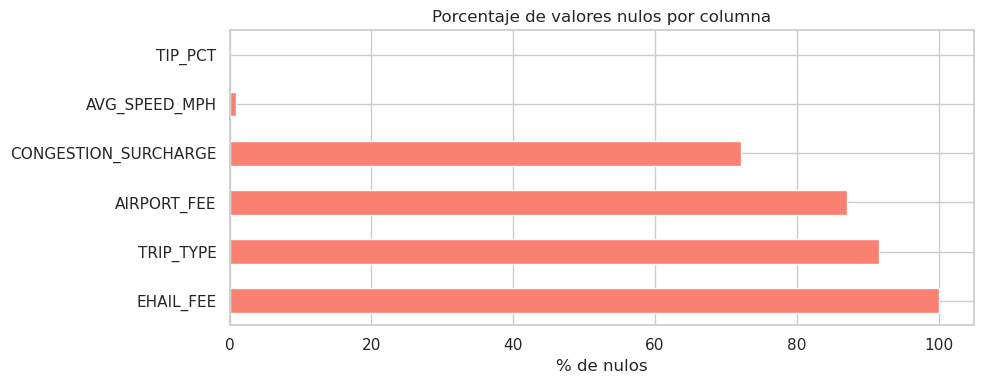

EHAIL_FEE               100.000000
TRIP_TYPE                91.575551
AIRPORT_FEE              87.041842
CONGESTION_SURCHARGE     72.062254
AVG_SPEED_MPH             0.828718
TIP_PCT                   0.029519


In [15]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(null_pct) * 0.4)))
null_pct.plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('% de nulos')
ax.set_title('Porcentaje de valores nulos por columna')
plt.tight_layout()
plt.show()

print(null_pct.to_string())

## 4. Variables objetivo: FARE_AMOUNT vs TOTAL_AMOUNT

Analizamos ambas candidatas para decidir cuál usar en la predicción de los modelos


In [14]:
# Estadísticas descriptivas de ambas
df[TARGET_CANDIDATES].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2)

,FARE_AMOUNT,TOTAL_AMOUNT
count,7689951.00,7689951.00
mean,13.36,17.48
std,12.90,15.71
min,0.00,0.00
1%,3.50,4.80
5%,4.50,6.30
25%,6.50,9.30
50%,9.50,12.96
75%,15.00,19.30
95%,37.50,48.35


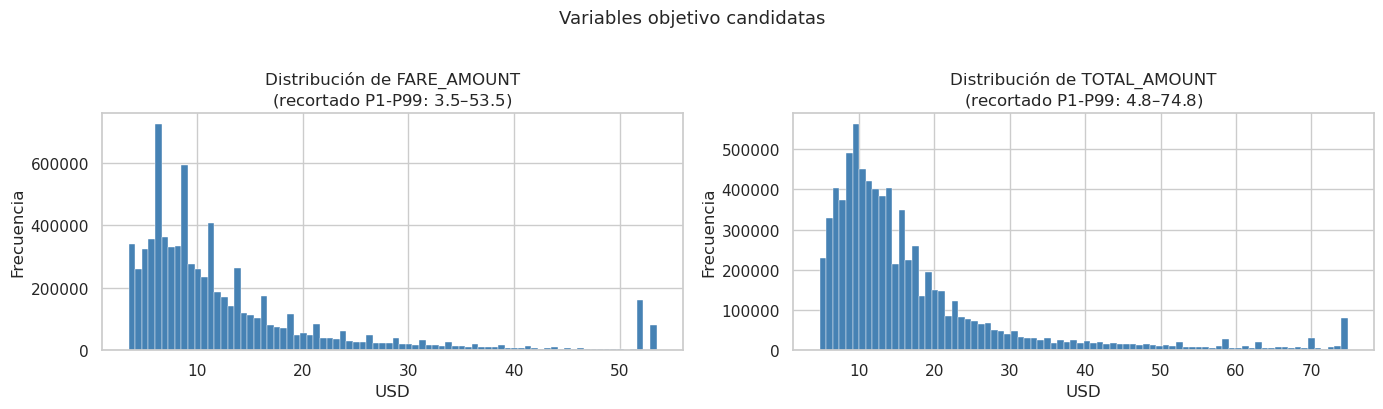

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, TARGET_CANDIDATES):
    lo, hi = df[col].quantile([0.01, 0.99])
    data = df[col].clip(lo, hi)
    ax.hist(data, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(f'Distribución de {col}\n(recortado P1-P99: ${lo:.1f} – ${hi:.1f})')
    ax.set_xlabel('USD')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Variables objetivo candidatas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
corr = df[TARGET_CANDIDATES].corr()
print(f"Correlación FARE_AMOUNT ↔ TOTAL_AMOUNT: {corr.iloc[0,1]:.4f}")

# Proporción de registros donde TOTAL > FARE 
pct_total_mayor = (df['TOTAL_AMOUNT'] > df['FARE_AMOUNT']).mean() * 100
print(f"Registros donde TOTAL_AMOUNT > FARE_AMOUNT: {pct_total_mayor:.1f}%")
print()
print("""DECISIÓN: Usamos FARE_AMOUNT como variable objetivo.
Razón: TOTAL_AMOUNT incluye propinas (TIP_AMOUNT) que dependen del pago,
no del viaje en sí. FARE_AMOUNT es la tarifa determinística del viaje.
Además, TOTAL_AMOUNT contiene los demás componentes (MTA_TAX, surcharges)
que son columnas de leakage — predecirlo sería casi trivial.""")

Correlación FARE_AMOUNT ↔ TOTAL_AMOUNT: 0.9742
Registros donde TOTAL_AMOUNT > FARE_AMOUNT: 99.9%

DECISIÓN: Usamos FARE_AMOUNT como variable objetivo.
Razón: TOTAL_AMOUNT incluye propinas (TIP_AMOUNT) que dependen del pago,
no del viaje en sí. FARE_AMOUNT es la tarifa determinística del viaje.
Además, TOTAL_AMOUNT contiene los demás componentes (MTA_TAX, surcharges)
que son columnas de leakage — predecirlo sería casi trivial.


## 5. Análisis de outliers en variables numéricas clave

In [18]:
NUM_COLS = ['FARE_AMOUNT', 'TRIP_DISTANCE', 'PASSENGER_COUNT',
            'TRIP_DURATION_MIN', 'AVG_SPEED_MPH']

stats = df[NUM_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3)
stats

,FARE_AMOUNT,TRIP_DISTANCE,PASSENGER_COUNT,TRIP_DURATION_MIN,AVG_SPEED_MPH
count,7689951.000,7689951.000,7689951.000,7689951.000,7626223.000
mean,13.364,2.997,1.573,16.907,11.666
std,12.904,3.768,1.221,60.829,6.280
min,0.000,0.000,0.000,0.000,0.000
1%,3.500,0.090,1.000,1.167,2.855
5%,4.500,0.500,1.000,3.000,4.604
25%,6.500,1.000,1.000,6.667,7.613
50%,9.500,1.700,1.000,11.167,10.286
75%,15.000,3.180,2.000,18.283,13.948
95%,37.500,10.800,5.000,36.833,24.036


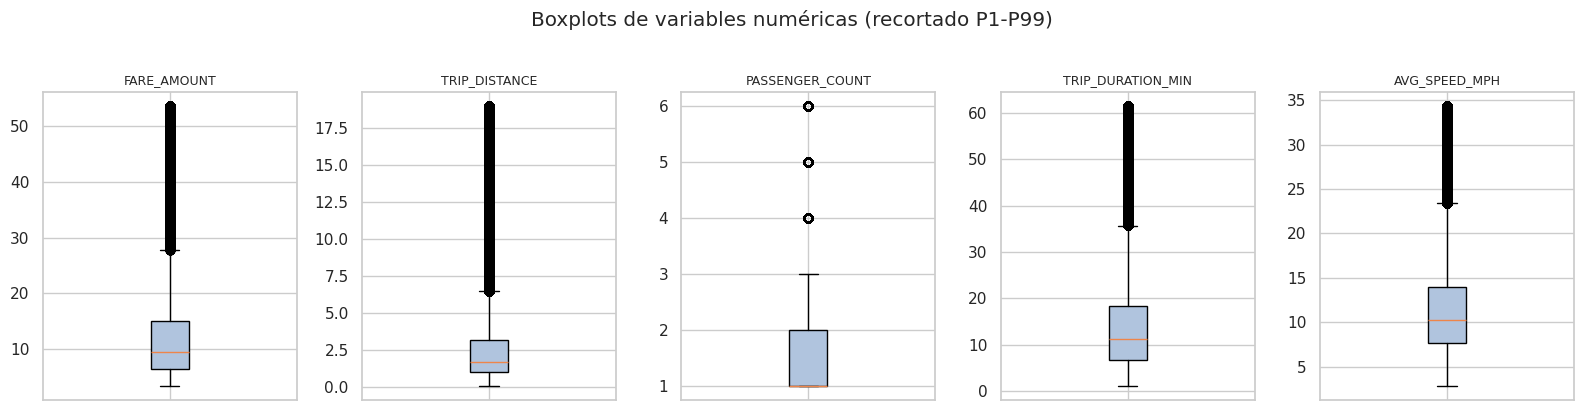

In [19]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(16, 4))

for ax, col in zip(axes, NUM_COLS):
    lo, hi = df[col].quantile([0.01, 0.99])
    data = df[col].dropna().clip(lo, hi)
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(col, fontsize=9)
    ax.set_xticklabels([])

plt.suptitle('Boxplots de variables numéricas (recortado P1-P99)', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# Cuantificación de outliers con IQR
print(f"{'Columna':<22} {'IQR':<10} {'Límite inf':<14} {'Límite sup':<14} {'% outliers'}")
print('-' * 75)
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR
    pct = ((df[col] < lo) | (df[col] > hi)).mean() * 100
    print(f"{col:<22} {IQR:<10.2f} {lo:<14.2f} {hi:<14.2f} {pct:.2f}%")

Columna                IQR        Límite inf     Límite sup     % outliers
---------------------------------------------------------------------------
FARE_AMOUNT            8.50       -6.25          27.75          8.79%
TRIP_DISTANCE          2.18       -2.27          6.45           10.77%
PASSENGER_COUNT        1.00       -0.50          3.50           8.79%
TRIP_DURATION_MIN      11.62      -10.76         35.71          5.44%
AVG_SPEED_MPH          6.33       -1.89          23.45          5.41%


## 6. Variables categóricas

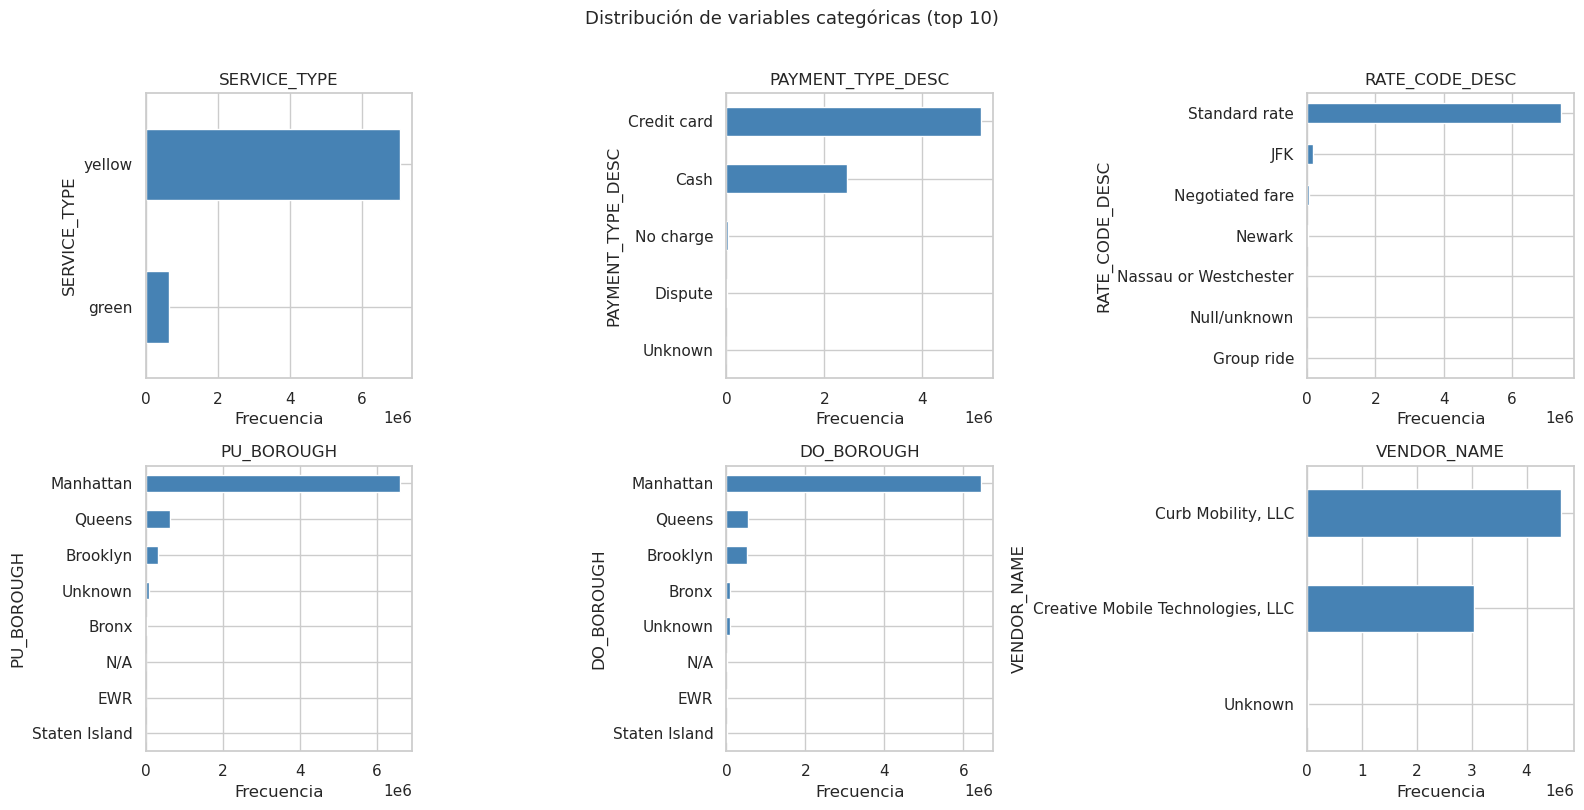

In [21]:
CAT_COLS = ['SERVICE_TYPE', 'PAYMENT_TYPE_DESC', 'RATE_CODE_DESC',
            'PU_BOROUGH', 'DO_BOROUGH', 'VENDOR_NAME']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, CAT_COLS):
    vc = df[col].value_counts().head(10)
    vc.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('Frecuencia')
    ax.invert_yaxis()

plt.suptitle('Distribución de variables categóricas (top 10)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Patrones temporales

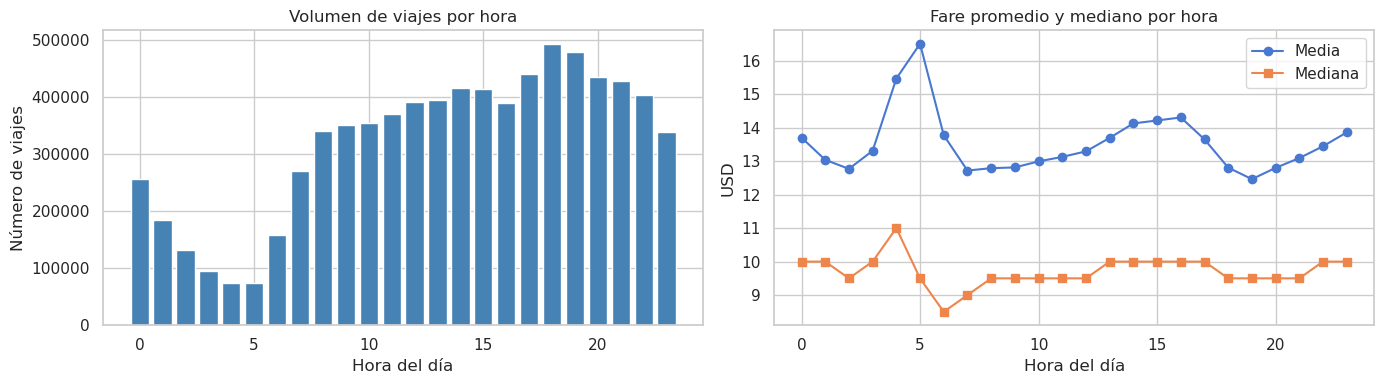

In [22]:
# Viajes y fare promedio por hora del día
hourly = df.groupby('PICKUP_HOUR').agg(
    VIAJES = ('FARE_AMOUNT', 'count'),
    AVG_FARE = ('FARE_AMOUNT', 'mean'),
    MEDIAN_FARE = ('FARE_AMOUNT', 'median'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(hourly['PICKUP_HOUR'], hourly['VIAJES'], color='steelblue')
ax1.set_title('Volumen de viajes por hora')
ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Número de viajes')

ax2.plot(hourly['PICKUP_HOUR'], hourly['AVG_FARE'],    label='Media', marker='o')
ax2.plot(hourly['PICKUP_HOUR'], hourly['MEDIAN_FARE'], label='Mediana', marker='s')
ax2.set_title('Fare promedio y mediano por hora')
ax2.set_xlabel('Hora del día')
ax2.set_ylabel('USD')
ax2.legend()

plt.tight_layout()
plt.show()

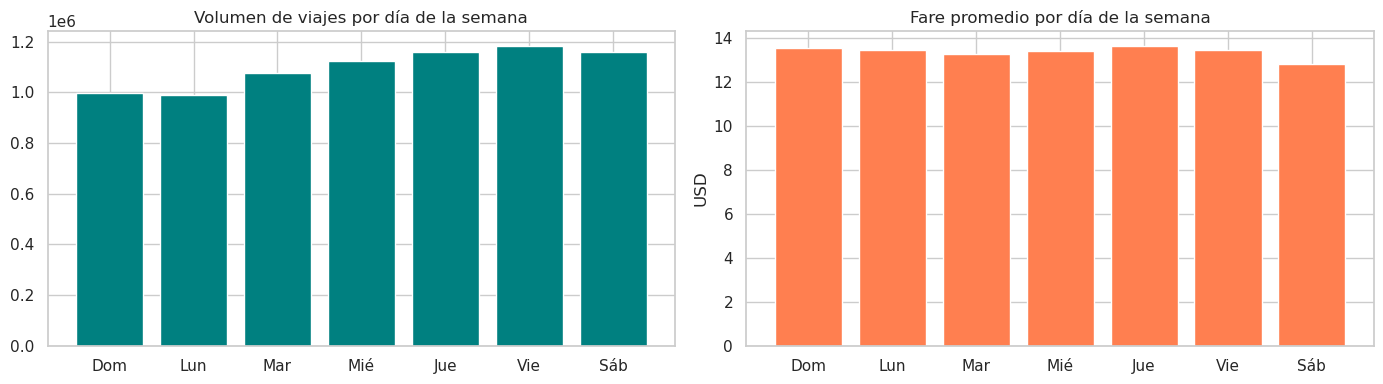

In [31]:
# Viajes y fare por día de la semana 
DOW_LABELS = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}

weekly = df.groupby('DAY_OF_WEEK').agg(
    VIAJES = ('FARE_AMOUNT', 'count'),
    AVG_FARE = ('FARE_AMOUNT', 'mean'),
).reset_index()
weekly['DIA'] = weekly['DAY_OF_WEEK'].map(DOW_LABELS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(weekly['DIA'], weekly['VIAJES'], color='teal')
ax1.set_title('Volumen de viajes por día de la semana')

ax2.bar(weekly['DIA'], weekly['AVG_FARE'], color='coral')
ax2.set_title('Fare promedio por día de la semana')
ax2.set_ylabel('USD')

plt.tight_layout()
plt.show()

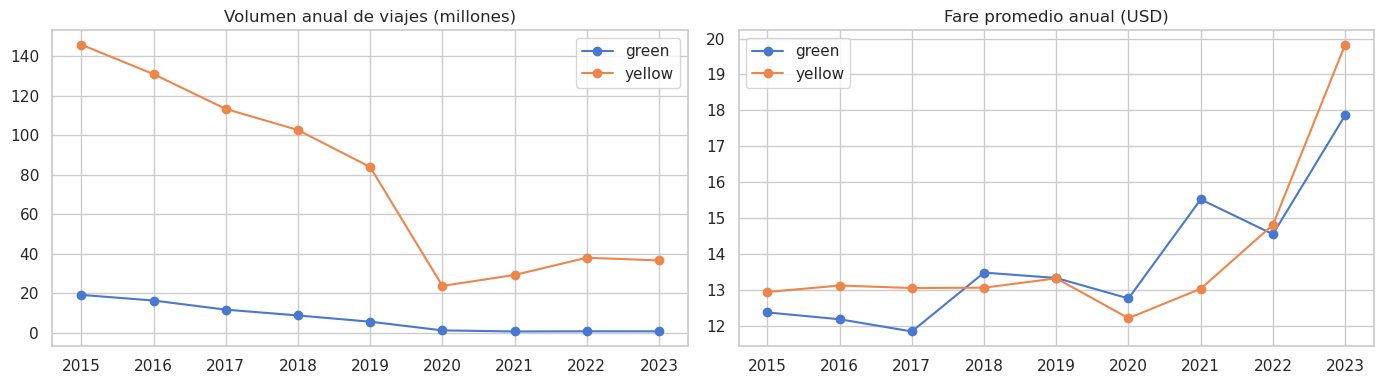

In [32]:
# Evolución anual: fare promedio y volumen
df_annual = query("""
    SELECT
        YEAR,
        SERVICE_TYPE,
        COUNT(*)                     AS VIAJES,
        ROUND(AVG(FARE_AMOUNT), 2)   AS AVG_FARE,
        ROUND(MEDIAN(FARE_AMOUNT), 2) AS MEDIAN_FARE
    FROM ANALYTICS.TRAIN_SET
    GROUP BY YEAR, SERVICE_TYPE
    ORDER BY YEAR, SERVICE_TYPE
""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for svc, grp in df_annual.groupby('SERVICE_TYPE'):
    ax1.plot(grp['YEAR'], grp['VIAJES'] / 1e6, marker='o', label=svc)
    ax2.plot(grp['YEAR'], grp['AVG_FARE'],      marker='o', label=svc)

ax1.set_title('Volumen anual de viajes (millones)')
ax1.legend()
ax2.set_title('Fare promedio anual (USD)')
ax2.legend()

plt.tight_layout()
plt.show()

## 8. Correlaciones entre features numéricas y el target

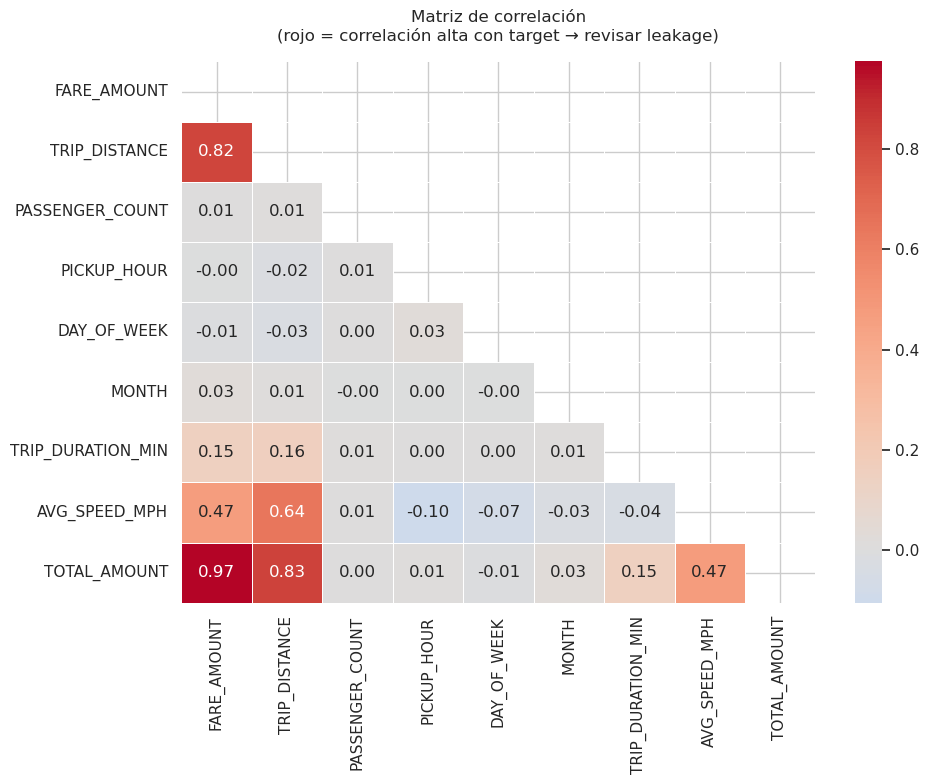


Correlación con FARE_AMOUNT (ordenado):
TOTAL_AMOUNT         0.974
TRIP_DISTANCE        0.823
AVG_SPEED_MPH        0.467
TRIP_DURATION_MIN    0.150
MONTH                0.026
PASSENGER_COUNT      0.008
PICKUP_HOUR         -0.003
DAY_OF_WEEK         -0.010


In [33]:
CORR_COLS = ['FARE_AMOUNT', 'TRIP_DISTANCE', 'PASSENGER_COUNT',
             'PICKUP_HOUR', 'DAY_OF_WEEK', 'MONTH',
             #leakage 
             'TRIP_DURATION_MIN', 'AVG_SPEED_MPH', 'TOTAL_AMOUNT']

corr_matrix = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlación\n(rojo = correlación alta con target → revisar leakage)', pad=15)
plt.tight_layout()
plt.show()

print("\nCorrelación con FARE_AMOUNT (ordenado):")
print(corr_matrix['FARE_AMOUNT'].drop('FARE_AMOUNT').sort_values(ascending=False).round(3).to_string())

## 9. Análisis espacial: top zonas de pickup

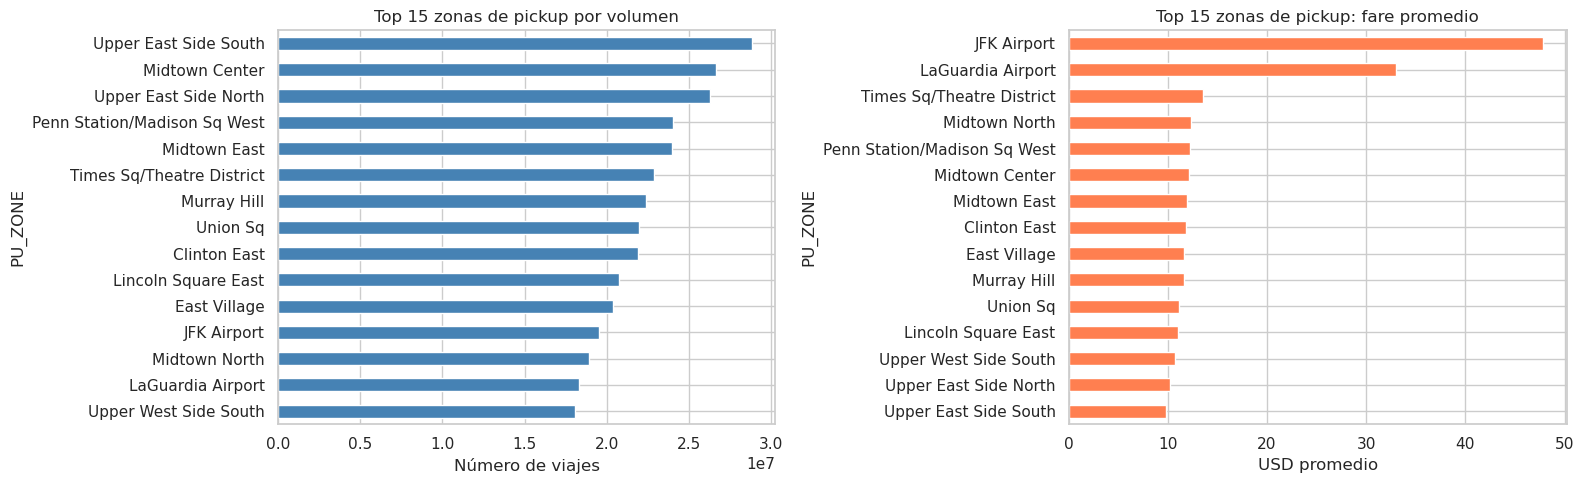

In [34]:
# Top 15 zonas por volumen y fare promedio 
df_zonas = query("""
    SELECT
        PU_BOROUGH,
        PU_ZONE,
        COUNT(*)                    AS VIAJES,
        ROUND(AVG(FARE_AMOUNT), 2)  AS AVG_FARE,
        ROUND(AVG(TRIP_DISTANCE), 2) AS AVG_DIST
    FROM ANALYTICS.TRAIN_SET
    GROUP BY PU_BOROUGH, PU_ZONE
    ORDER BY VIAJES DESC
    LIMIT 15
""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

df_zonas.sort_values('VIAJES').plot(
    kind='barh', x='PU_ZONE', y='VIAJES', ax=ax1, legend=False, color='steelblue')
ax1.set_title('Top 15 zonas de pickup por volumen')
ax1.set_xlabel('Número de viajes')

df_zonas.sort_values('AVG_FARE').plot(
    kind='barh', x='PU_ZONE', y='AVG_FARE', ax=ax2, legend=False, color='coral')
ax2.set_title('Top 15 zonas de pickup: fare promedio')
ax2.set_xlabel('USD promedio')

plt.tight_layout()
plt.show()

## 10. Resumen 



In [35]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║              RESUMEN EDA — DECISIONES PARA CLEANING             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  VARIABLE OBJETIVO ELEGIDA: FARE_AMOUNT                          ║
║  Razón: TOTAL_AMOUNT incluye propinas y surcharges (leakage).    ║
║                                                                  ║
║  OUTLIERS A FILTRAR EN CLEANING:                                 ║
║  • FARE_AMOUNT   : mantener [2.50, 200]  (tarifa mínima NYC=2.5) ║
║  • TRIP_DISTANCE : mantener [0.1, 100]   (millas, en NYC)        ║
║  • PASSENGER_COUNT: mantener [1, 6]      (max oficial TLC)       ║
║                                                                  ║
║  COLUMNAS DE LEAKAGE (EXCLUIR del modelo):                       ║
║  • DROPOFF_DATETIME, DROPOFF_DATE, DROPOFF_HOUR                  ║
║  • TRIP_DURATION_MIN, AVG_SPEED_MPH                              ║
║  • TIP_AMOUNT, TIP_PCT                                           ║
║  • EXTRA, MTA_TAX, TOLLS_AMOUNT, IMPROVEMENT_SURCHARGE           ║
║  • CONGESTION_SURCHARGE, AIRPORT_FEE, EHAIL_FEE                  ║
║  • TOTAL_AMOUNT (es la otra variable objetivo)                   ║
║                                                                  ║
║  FEATURES VÁLIDAS PARA EL MODELO:                                ║
║  • PICKUP_HOUR, DAY_OF_WEEK, MONTH, YEAR                         ║
║  • PU_LOCATION_ID, DO_LOCATION_ID, PU_BOROUGH, DO_BOROUGH        ║
║  • TRIP_DISTANCE, PASSENGER_COUNT                                ║
║  • SERVICE_TYPE, RATE_CODE_ID, PAYMENT_TYPE, VENDOR_ID           ║
║  • STORE_AND_FWD_FLAG, TRIP_TYPE (Green)                         ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║              RESUMEN EDA — DECISIONES PARA CLEANING             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  VARIABLE OBJETIVO ELEGIDA: FARE_AMOUNT                          ║
║  Razón: TOTAL_AMOUNT incluye propinas y surcharges (leakage).    ║
║                                                                  ║
║  OUTLIERS A FILTRAR EN CLEANING:                                 ║
║  • FARE_AMOUNT   : mantener [2.50, 200]  (tarifa mínima NYC=2.5) ║
║  • TRIP_DISTANCE : mantener [0.1, 100]   (millas, en NYC)        ║
║  • PASSENGER_COUNT: mantener [1, 6]      (max oficial TLC)       ║
║                                                                  ║
║  COLUMNAS DE LEAKAGE (EXCLUIR del modelo):                       ║
║  • DROPOFF_DATETIME, DROPOFF_DATE, DROPOFF_HOUR                  ║
║  • TRIP_DURATION_MIN, AVG_SPEED_